<a href="https://colab.research.google.com/github/MhiyaJ/My-GIS-Stuff/blob/main/***Municipality%20Merge%202.0%20(ps01).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [112]:
%%capture
#!pip install geopandas #==1.0.1
#!pip install mapclassify #sometimes have to install library which you get from https://pypi.org/

In [113]:
import os, zipfile #basics
import pandas as pd #data management
import matplotlib.pyplot as plt #vis

import geopandas as gpd #gis/maps: a sister of pandas; does the job;
#tho not as fancy-interactive as folium or leafmap https://geopandas.org/

import mapclassify #need for thematic map classification

import seaborn as sns

#will display all output not just last command
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from google.colab import files #to download from colab onto hd

#from google.colab import data_table
#data_table.enable_dataframe_formatter() #this enables spreadsheet view upon calling dataframe (without() )
from google.colab.data_table import DataTable
DataTable.max_columns = 250

In [114]:
#!python --version
gpd.__version__

'1.1.4'

**Hypothesis**: Limited access to affordable after-school programs contributes to increased social disengagement and delinquent behavior among students living in urban areas.

**Project Description:** Identifying the availability and accessibility of after school programs in low income areas and examining their relationship to youth social disengagement and delinquent behaviors.  

*Variables:* After school programs, economically disadvantaged youth population, delinquent/disengaged behavior, household income

Unified School Districts in NJ - includes and operates primary, secondary and high school as one district

Census data used to create boundaries for unified school districts.

NJ Office of GIS used Census data to establish unified school district boundaries in two areas, on and near military bases, were edited to reflect special arrangements made for students residing in base housing.

NJDOE used set of grades, based on financial responsibility, to assign the data for each child to exactly one school district, except for districts covering Joint Base McGuire-Dix-Lakehurst in Burlington County.

In [115]:
import zipfile
import geopandas as gpd

#NJ Office of GIS (March 14, 2025), Municipal Boundaries of NJ, Hosted, 3857
#https://njogis-newjersey.opendata.arcgis.com/datasets/newjersey::municipal-boundaries-of-nj-hosted-3857/about)
#code used from class
! wget -q -O MunicipNJ_Municipalities_3857.zip https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/NJ_Municipalities_3857_-3177345712037447640.zip

zip_ref = zipfile.ZipFile('MunicipNJ_Municipalities_3857.zip', 'r'); zip_ref.extractall(); zip_ref.close()

njMun=gpd.read_file('NJ_Municipalities_3857.shp') #labeled shapefile njSch
#With the school district shapefile made with municipalities in mind and doesn't include all school districts when merging, a municipality shape file was used.

<Axes: >

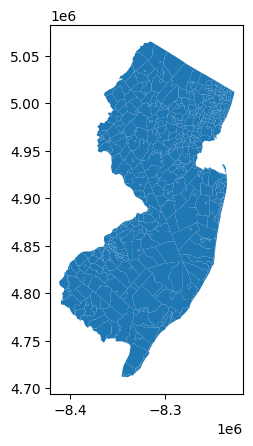

In [116]:
njMun.plot()

In [117]:
njMun.columns #identifies column headings

Index(['MUN', 'COUNTY', 'MUN_LABEL', 'MUN_TYPE', 'NAME', 'GNIS_NAME', 'GNIS',
       'SSN', 'MUN_CODE', 'CENSUS2020', 'ACRES', 'SQ_MILES', 'POP2020',
       'POP2010', 'POP2000', 'POP1990', 'POP1980', 'POPDEN2020', 'POPDEN2010',
       'POPDEN2000', 'POPDEN1990', 'POPDEN1980', 'COUNTY_MUN', 'geometry'],
      dtype='object')

In [118]:
njMun=njMun[njMun.COUNTY=='CAMDEN'] #keeps just Camden

In [119]:
njMun[['MUN','COUNTY','MUN_LABEL','MUN_TYPE','NAME','GNIS_NAME']]

,MUN,COUNTY,MUN_LABEL,MUN_TYPE,NAME,GNIS_NAME
59,CHESILHURST BORO,CAMDEN,Chesilhurst Borough,Borough,Chesilhurst Borough,Borough of Chesilhurst
63,WINSLOW TWP,CAMDEN,Winslow Township,Township,Winslow Township,Township of Winslow
65,WATERFORD TWP,CAMDEN,Waterford Township,Township,Waterford Township,Township of Waterford
66,PINE HILL BORO,CAMDEN,Pine Hill Borough,Borough,Pine Hill Borough,Borough of Pine Hill
67,BERLIN BORO,CAMDEN,Berlin Borough,Borough,Berlin Borough,Borough of Berlin
68,CLEMENTON BORO,CAMDEN,Clementon Borough,Borough,Clementon Borough,Borough of Clementon
69,LAUREL SPRINGS BORO,CAMDEN,Laurel Springs Borough,Borough,Laurel Springs Borough,Borough of Laurel Springs
72,LINDENWOLD BORO,CAMDEN,Lindenwold Borough,Borough,Lindenwold Borough,Borough of Lindenwold
73,STRATFORD BORO,CAMDEN,Stratford Borough,Borough,Stratford Borough,Borough of Stratford
75,HI-NELLA BORO,CAMDEN,Hi-Nella Borough,Borough,Hi-Nella Borough,Borough of Hi-Nella


<Axes: >

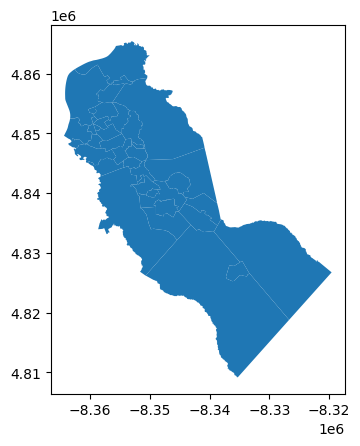

In [120]:
njMun.plot()

In [121]:
DisXls=pd.read_excel ('https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/Economically%20Disadvantage%20Youth.xlsx', header = 3)

In [122]:
DisXls1=DisXls[DisXls['SchoolYear'] =='2024-25'][['CountyName','DistrictCode','DistrictName','Economically Disadvantaged Students']]
DisXls1.rename(columns={'DistrictName' : 'District'}, inplace=True)
DisXls1['District'] = DisXls1['District'].str.upper()
DisXls1

,CountyName,DistrictCode,District,Economically Disadvantaged Students
4,Camden,150,AUDUBON PUBLIC SCHOOL DISTRICT,24.5%
9,Camden,190,BARRINGTON SCHOOL DISTRICT,34.1%
14,Camden,260,BELLMAWR PUBLIC SCHOOL DISTRICT,57.8%
19,Camden,330,BERLIN BOROUGH SCHOOL DISTRICT,25.2%
24,Camden,340,BERLIN TOWNSHIP SCHOOL DISTRICT,53.3%
29,Camden,390,BLACK HORSE PIKE REGIONAL SCHOOL DISTRICT,44.9%
34,Camden,580,BROOKLAWN PUBLIC SCHOOL DISTRICT,70.7%
39,Camden,680,CAMDEN CITY SCHOOL DISTRICT,88.5%
44,Camden,700,CAMDEN COUNTY TECHNICAL SCHOOL DISTRICT,56.1%
49,Camden,800,CHERRY HILL SCHOOL DISTRICT,23.2%


In [123]:
#njMun[['MUN','GEOID']]
#code from class to strip white space for merging
DisXls1['c']=DisXls1.District.str.strip()
njMun['c']=njMun.MUN_LABEL.str.strip()

/usr/local/lib/python3.13/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [124]:
#code from Gemini to make all upper case for merging
DisXls1['District'] = DisXls1['District'].str.upper()
njMun['MUN_LABEL'] = njMun['MUN_LABEL'].str.upper()
njMun['first_word_District'] = njMun['MUN_LABEL'].str.split().str[0]

/usr/local/lib/python3.13/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [125]:
#code from Gemini to match only the first word which is the name of the school and municipality
DisXls1['first_word_District'] = DisXls1['District'].str.split().str[0]

In [126]:
DisXls1

,CountyName,DistrictCode,District,Economically Disadvantaged Students,c,first_word_District
4,Camden,150,AUDUBON PUBLIC SCHOOL DISTRICT,24.5%,AUDUBON PUBLIC SCHOOL DISTRICT,AUDUBON
9,Camden,190,BARRINGTON SCHOOL DISTRICT,34.1%,BARRINGTON SCHOOL DISTRICT,BARRINGTON
14,Camden,260,BELLMAWR PUBLIC SCHOOL DISTRICT,57.8%,BELLMAWR PUBLIC SCHOOL DISTRICT,BELLMAWR
19,Camden,330,BERLIN BOROUGH SCHOOL DISTRICT,25.2%,BERLIN BOROUGH SCHOOL DISTRICT,BERLIN
24,Camden,340,BERLIN TOWNSHIP SCHOOL DISTRICT,53.3%,BERLIN TOWNSHIP SCHOOL DISTRICT,BERLIN
29,Camden,390,BLACK HORSE PIKE REGIONAL SCHOOL DISTRICT,44.9%,BLACK HORSE PIKE REGIONAL SCHOOL DISTRICT,BLACK
34,Camden,580,BROOKLAWN PUBLIC SCHOOL DISTRICT,70.7%,BROOKLAWN PUBLIC SCHOOL DISTRICT,BROOKLAWN
39,Camden,680,CAMDEN CITY SCHOOL DISTRICT,88.5%,CAMDEN CITY SCHOOL DISTRICT,CAMDEN
44,Camden,700,CAMDEN COUNTY TECHNICAL SCHOOL DISTRICT,56.1%,CAMDEN COUNTY TECHNICAL SCHOOL DISTRICT,CAMDEN
49,Camden,800,CHERRY HILL SCHOOL DISTRICT,23.2%,CHERRY HILL SCHOOL DISTRICT,CHERRY


In [127]:
#merged newly created column "first_word_MUN", MUN and Camden County
a1 = pd.merge(njMun, DisXls1, left_on=['first_word_District'], right_on=['first_word_District'], how='outer', indicator=True)
a1

,MUN,COUNTY,MUN_LABEL,MUN_TYPE,NAME,GNIS_NAME,GNIS,SSN,MUN_CODE,CENSUS2020,...,COUNTY_MUN,geometry,c_x,first_word_District,CountyName,DistrictCode,District,Economically Disadvantaged Students,c_y,_merge
0,AUDUBON PARK BORO,CAMDEN,AUDUBON PARK BOROUGH,Borough,Audubon Park Borough,Borough of Audubon Park,885145,0402,0402,3400702230,...,"Camden, Audubon Park Borough","POLYGON ((-8359204.93 4851488.338, -8359200.94...",Audubon Park Borough,AUDUBON,Camden,150.0,AUDUBON PUBLIC SCHOOL DISTRICT,24.5%,AUDUBON PUBLIC SCHOOL DISTRICT,both
1,AUDUBON BORO,CAMDEN,AUDUBON BOROUGH,Borough,Audubon Borough,Borough of Audubon,885144,0401,0401,3400702200,...,"Camden, Audubon Borough","POLYGON ((-8355680.681 4850611.687, -8354703.6...",Audubon Borough,AUDUBON,Camden,150.0,AUDUBON PUBLIC SCHOOL DISTRICT,24.5%,AUDUBON PUBLIC SCHOOL DISTRICT,both
2,BARRINGTON BORO,CAMDEN,BARRINGTON BOROUGH,Borough,Barrington Borough,Borough of Barrington,885149,0403,0403,3400703250,...,"Camden, Barrington Borough","POLYGON ((-8353103.288 4848678.472, -8353099.5...",Barrington Borough,BARRINGTON,Camden,190.0,BARRINGTON SCHOOL DISTRICT,34.1%,BARRINGTON SCHOOL DISTRICT,both
3,BELLMAWR BORO,CAMDEN,BELLMAWR BOROUGH,Borough,Bellmawr Borough,Borough of Bellmawr,885154,0404,0404,3400704750,...,"Camden, Bellmawr Borough","POLYGON ((-8360421.238 4845076.754, -8360429.8...",Bellmawr Borough,BELLMAWR,Camden,260.0,BELLMAWR PUBLIC SCHOOL DISTRICT,57.8%,BELLMAWR PUBLIC SCHOOL DISTRICT,both
4,BERLIN BORO,CAMDEN,BERLIN BOROUGH,Borough,Berlin Borough,Borough of Berlin,885158,0405,0405,3400705440,...,"Camden, Berlin Borough","POLYGON ((-8338704.647 4834585.253, -8338724.4...",Berlin Borough,BERLIN,Camden,330.0,BERLIN BOROUGH SCHOOL DISTRICT,25.2%,BERLIN BOROUGH SCHOOL DISTRICT,both
5,BERLIN BORO,CAMDEN,BERLIN BOROUGH,Borough,Berlin Borough,Borough of Berlin,885158,0405,0405,3400705440,...,"Camden, Berlin Borough","POLYGON ((-8338704.647 4834585.253, -8338724.4...",Berlin Borough,BERLIN,Camden,340.0,BERLIN TOWNSHIP SCHOOL DISTRICT,53.3%,BERLIN TOWNSHIP SCHOOL DISTRICT,both
6,BERLIN TWP,CAMDEN,BERLIN TOWNSHIP,Township,Berlin Township,Township of Berlin,882152,0406,0406,3400705470,...,"Camden, Berlin Township","POLYGON ((-8338754.768 4838332.25, -8338752.73...",Berlin Township,BERLIN,Camden,330.0,BERLIN BOROUGH SCHOOL DISTRICT,25.2%,BERLIN BOROUGH SCHOOL DISTRICT,both
7,BERLIN TWP,CAMDEN,BERLIN TOWNSHIP,Township,Berlin Township,Township of Berlin,882152,0406,0406,3400705470,...,"Camden, Berlin Township","POLYGON ((-8338754.768 4838332.25, -8338752.73...",Berlin Township,BERLIN,Camden,340.0,BERLIN TOWNSHIP SCHOOL DISTRICT,53.3%,BERLIN TOWNSHIP SCHOOL DISTRICT,both
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,None,NaN,BLACK,Camden,390.0,BLACK HORSE PIKE REGIONAL SCHOOL DISTRICT,44.9%,BLACK HORSE PIKE REGIONAL SCHOOL DISTRICT,right_only
9,BROOKLAWN BORO,CAMDEN,BROOKLAWN BOROUGH,Borough,Brooklawn Borough,Borough of Brooklawn,885172,0407,0407,3400708170,...,"Camden, Brooklawn Borough","POLYGON ((-8361015.51 4848225.583, -8361091.56...",Brooklawn Borough,BROOKLAWN,Camden,580.0,BROOKLAWN PUBLIC SCHOOL DISTRICT,70.7%,BROOKLAWN PUBLIC SCHOOL DISTRICT,both


In [128]:
a1._merge.value_counts()

,count
_merge,
both,41
right_only,8
left_only,3


<Axes: >

Text(0.5, 1.0, '% of Economically Disadvantaged Students\n2024 - 2025 School Year')

Text(0.35, 0.122, 'New Jersey, Department of Education\n            2024 - 2025 Performance Reports Database - Excel\n            Data from https://www.nj.gov/education/spr/download/\n            ')

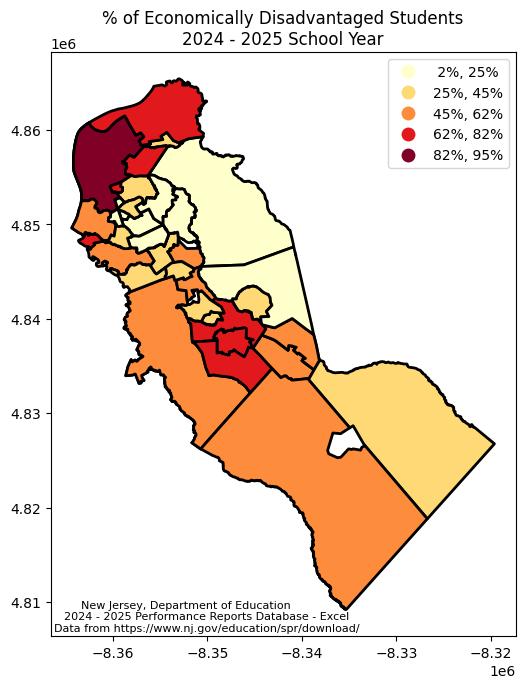

In [129]:
fig, ax = plt.subplots(figsize=(6,8))

# Convert the 'Economically Disadvantaged Students' column to numeric, handling NaN values
a1['Economically Disadvantaged Students'] = a1['Economically Disadvantaged Students'].apply(lambda x: float(x.replace('%', '')) if isinstance(x, str) else x)

a1.plot(ax=ax,figsize=(6,8),column='Economically Disadvantaged Students',legend=True,cmap='YlOrRd',
          scheme='natural_breaks',k=5, edgecolor='black',linewidth=2,legend_kwds= {"fmt": "{:.0f}%"})
ax.set_title('''% of Economically Disadvantaged Students
2024 - 2025 School Year''')
#ax.annotate('Note added to chart with minimum parameters', xy = (200000, 1000))
plt.figtext(0.35, 0.122,
            '''New Jersey, Department of Education
            2024 - 2025 Performance Reports Database - Excel
            Data from https://www.nj.gov/education/spr/download/
            ''',
            ha="center", fontsize=8, #bbox={"facecolor":"white", "alpha":0.5, "pad":5}
            )

In [130]:
EnrXls = pd.read_excel('https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/Camden%20County%20School%20Enrollment%20by%20School%20Level%202024%20-%20Public%20School%20Only.xlsx')

In [131]:
EnrXls.head(7)

,,"Audubon borough, Camden County, New Jersey","Audubon Park borough, Camden County, New Jersey","Barrington borough, Camden County, New Jersey","Bellmawr borough, Camden County, New Jersey","Berlin borough, Camden County, New Jersey","Berlin township, Camden County, New Jersey","Brooklawn borough, Camden County, New Jersey","Camden city, Camden County, New Jersey","Cherry Hill township, Camden County, New Jersey",...,"Pennsauken township, Camden County, New Jersey","Pine Hill borough, Camden County, New Jersey","Runnemede borough, Camden County, New Jersey","Somerdale borough, Camden County, New Jersey","Stratford borough, Camden County, New Jersey","Tavistock borough, Camden County, New Jersey","Voorhees township, Camden County, New Jersey","Waterford township, Camden County, New Jersey","Winslow township, Camden County, New Jersey","Woodlynne borough, Camden County, New Jersey"
0,Pre-School,90,0,11,128,26,26,4,987,332,...,298,250,100,93,32,0,67,199,118,10
1,K-8,767,50,277,1296,917,509,145,8628,7492,...,3725,855,601,366,673,2,3439,1029,3284,408
2,9-12,265,36,262,483,527,219,59,4221,2957,...,1869,463,326,168,301,0,1632,281,2049,204


In [132]:
EnrXls = (EnrXls
  .rename(columns={EnrXls.columns[0]: 'School_Level'}) # Rename the first unnamed column
  .melt(
      id_vars=['School_Level'],
      var_name='Munis', # New column for district names
      value_name='Enrollment' # New column for enrollment values
  )
)

# Clean up district names (remove ', Camden County, New Jersey')
EnrXls['Munis'] = EnrXls['Munis'].str.replace(', Camden County, New Jersey', '', regex=False).str.strip()

# Convert 'Enrollment' to numeric, coercing errors to NaN
EnrXls['Enrollment'] = pd.to_numeric(EnrXls['Enrollment'], errors='coerce')

In [133]:
EnrXls

,School_Level,Munis,Enrollment
0,Pre-School,Audubon borough,90
1,K-8,Audubon borough,767
2,9-12,Audubon borough,265
3,Pre-School,Audubon Park borough,0
4,K-8,Audubon Park borough,50
...,...,...,...
100,K-8,Winslow township,3284
101,9-12,Winslow township,2049
102,Pre-School,Woodlynne borough,10
103,K-8,Woodlynne borough,408


In [134]:
EnrXls['Munis'] = EnrXls['Munis'].str.upper()
enr9_12=EnrXls[EnrXls.School_Level.str.strip()=='9-12'] #aok: keep it simple for now
enr9_12.loc[enr9_12['Munis'] == 'GLOUCESTER CITY CITY','mun'] = 'GLOUCESTER CITY'
enr9_12.loc[enr9_12['Munis'] == 'MT. EPHRAIM','mun'] = 'MOUNT EPHRAIM'
enr9_12

/tmp/ipykernel_6822/428188890.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  enr9_12.loc[enr9_12['Munis'] == 'GLOUCESTER CITY CITY','mun'] = 'GLOUCESTER CITY'


,School_Level,Munis,Enrollment,mun
2,9-12,AUDUBON BOROUGH,265,NaN
5,9-12,AUDUBON PARK BOROUGH,36,NaN
8,9-12,BARRINGTON BOROUGH,262,NaN
11,9-12,BELLMAWR BOROUGH,483,NaN
14,9-12,BERLIN BOROUGH,527,NaN
17,9-12,BERLIN TOWNSHIP,219,NaN
20,9-12,BROOKLAWN BOROUGH,59,NaN
23,9-12,CAMDEN CITY,4221,NaN
26,9-12,CHERRY HILL TOWNSHIP,2957,NaN
29,9-12,CHESILHURST BOROUGH,41,NaN


In [135]:
a2 = pd.merge(njMun, enr9_12, left_on=['MUN_LABEL'], right_on=['Munis'], how='outer', indicator=True)
a2

,MUN,COUNTY,MUN_LABEL,MUN_TYPE,NAME,GNIS_NAME,GNIS,SSN,MUN_CODE,CENSUS2020,...,POPDEN1980,COUNTY_MUN,geometry,c,first_word_District,School_Level,Munis,Enrollment,mun,_merge
0,AUDUBON BORO,CAMDEN,AUDUBON BOROUGH,Borough,Audubon Borough,Borough of Audubon,885144,0401,0401,3400702200,...,6386.0,"Camden, Audubon Borough","POLYGON ((-8355680.681 4850611.687, -8354703.6...",Audubon Borough,AUDUBON,9-12,AUDUBON BOROUGH,265.0,NaN,both
1,AUDUBON PARK BORO,CAMDEN,AUDUBON PARK BOROUGH,Borough,Audubon Park Borough,Borough of Audubon Park,885145,0402,0402,3400702230,...,7747.0,"Camden, Audubon Park Borough","POLYGON ((-8359204.93 4851488.338, -8359200.94...",Audubon Park Borough,AUDUBON,9-12,AUDUBON PARK BOROUGH,36.0,NaN,both
2,BARRINGTON BORO,CAMDEN,BARRINGTON BOROUGH,Borough,Barrington Borough,Borough of Barrington,885149,0403,0403,3400703250,...,4692.0,"Camden, Barrington Borough","POLYGON ((-8353103.288 4848678.472, -8353099.5...",Barrington Borough,BARRINGTON,9-12,BARRINGTON BOROUGH,262.0,NaN,both
3,BELLMAWR BORO,CAMDEN,BELLMAWR BOROUGH,Borough,Bellmawr Borough,Borough of Bellmawr,885154,0404,0404,3400704750,...,4428.0,"Camden, Bellmawr Borough","POLYGON ((-8360421.238 4845076.754, -8360429.8...",Bellmawr Borough,BELLMAWR,9-12,BELLMAWR BOROUGH,483.0,NaN,both
4,BERLIN BORO,CAMDEN,BERLIN BOROUGH,Borough,Berlin Borough,Borough of Berlin,885158,0405,0405,3400705440,...,1600.0,"Camden, Berlin Borough","POLYGON ((-8338704.647 4834585.253, -8338724.4...",Berlin Borough,BERLIN,9-12,BERLIN BOROUGH,527.0,NaN,both
5,BERLIN TWP,CAMDEN,BERLIN TOWNSHIP,Township,Berlin Township,Township of Berlin,882152,0406,0406,3400705470,...,1601.0,"Camden, Berlin Township","POLYGON ((-8338754.768 4838332.25, -8338752.73...",Berlin Township,BERLIN,9-12,BERLIN TOWNSHIP,219.0,NaN,both
6,BROOKLAWN BORO,CAMDEN,BROOKLAWN BOROUGH,Borough,Brooklawn Borough,Borough of Brooklawn,885172,0407,0407,3400708170,...,4018.0,"Camden, Brooklawn Borough","POLYGON ((-8361015.51 4848225.583, -8361091.56...",Brooklawn Borough,BROOKLAWN,9-12,BROOKLAWN BOROUGH,59.0,NaN,both
7,CAMDEN CITY,CAMDEN,CAMDEN CITY,City,Camden,City of Camden,885177,0408,0408,3400710000,...,8111.0,"Camden, Camden","POLYGON ((-8357871.519 4859928.131, -8357818.2...",Camden City,CAMDEN,9-12,CAMDEN CITY,4221.0,NaN,both
8,CHERRY HILL TWP,CAMDEN,CHERRY HILL TOWNSHIP,Township,Cherry Hill Township,Township of Cherry Hill,882155,0409,0409,3400712280,...,2845.0,"Camden, Cherry Hill Township","POLYGON ((-8347185.878 4855392.365, -8347182.9...",Cherry Hill Township,CHERRY,9-12,CHERRY HILL TOWNSHIP,2957.0,NaN,both
9,CHESILHURST BORO,CAMDEN,CHESILHURST BOROUGH,Borough,Chesilhurst Borough,Borough of Chesilhurst,885183,0410,0410,3400712550,...,922.0,"Camden, Chesilhurst Borough","POLYGON ((-8333397.531 4826650.661, -8333343.7...",Chesilhurst Borough,CHESILHURST,9-12,CHESILHURST BOROUGH,41.0,NaN,both


In [136]:
a2._merge.value_counts()

,count
_merge,
both,34
left_only,2
right_only,1


<Axes: >

Text(0.5, 1.0, 'Total Students Enrolled in Public School\n2024 - 2025 School Year')

Text(0.35, 0.122, 'US Census: American Community Survey 5 Year\n            Downloaded Excel via:Shaperfile\n\n            ')

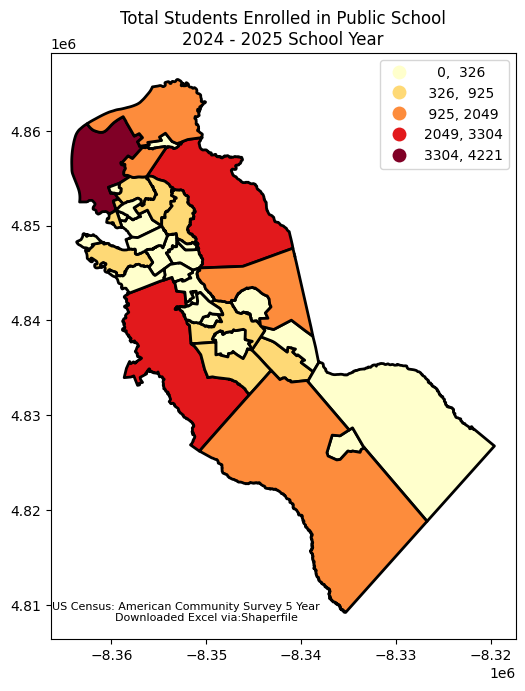

In [137]:
fig, ax = plt.subplots(figsize=(6,8))

a2.plot(ax=ax,figsize=(6,8),column='Enrollment',legend=True,cmap='YlOrRd',
          scheme='natural_breaks',k=5, edgecolor='black',linewidth=2,legend_kwds= {"fmt": "{:.0f}"})
ax.set_title('''Total Students Enrolled in Public School
2024 - 2025 School Year''')
#ax.annotate('Note added to chart with minimum parameters', xy = (200000, 1000))
plt.figtext(0.35, 0.122,
            '''US Census: American Community Survey 5 Year
            Downloaded Excel via:Shaperfile

            ''',
            ha="center", fontsize=8, #bbox={"facecolor":"white", "alpha":0.5, "pad":5}
            )

In [138]:
#Social Explorer; U.S. Census Bureau. Median Household Income (In 2024 Inflation Adjusted Dollars), 2024. Prepared by Social Explorer. https://www.socialexplorer.com/data/ACS2024_5yr/metadata?ds=SE&table=A14006 (accessed 27 September 2026 at 10:01:00 GMT-4).

In [139]:
IncXls = pd.read_excel('https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/Camden%20County%20Median%20Household%20Income.xlsx')

HTTPError: HTTP Error 404: Not Found

In [ ]:
IncXls.head(7)